 CAR PRICE PREDICTION WITH MACHINE LEARNING 

= To bulid a machine learning model that predicts the selling price of car based on its features.

1. IMPORT LIBRARIES

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

2. LOAD DATASET

In [2]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


3. DATASET INFORMATION

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


4. SATISTICAL SUMMARY

In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


5. DATA CLEANING 

In [5]:
print("Shape", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:",df.duplicated().sum())

df = df.drop_duplicates()

print("\nNew Shape:",df.shape)


Shape (301, 9)

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows: 2

New Shape: (299, 9)


6. DATA PREPROCESSING

In [8]:
encoder = LabelEncoder()

df["Car_Name"] = encoder.fit_transform(df["Car_Name"])
df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])
df["Selling_type"] = encoder.fit_transform(df["Selling_type"])
df["Transmission"] = encoder.fit_transform(df["Transmission"])
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,90,2014,3.35,5.59,27000,2,0,1,0
1,93,2013,4.75,9.54,43000,1,0,1,0
2,68,2017,7.25,9.85,6900,2,0,1,0
3,96,2011,2.85,4.15,5200,2,0,1,0
4,92,2014,4.60,6.87,42450,1,0,1,0


7. FEATURE SELECTION 

In [9]:
X = df.drop("Selling_Price",axis = 1)
y = df["Selling_Price"]

print(X.head())
print(y.head())


   Car_Name  Year  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0        90  2014           5.59       27000          2             0   
1        93  2013           9.54       43000          1             0   
2        68  2017           9.85        6900          2             0   
3        96  2011           4.15        5200          2             0   
4        92  2014           6.87       42450          1             0   

   Transmission  Owner  
0             1      0  
1             1      0  
2             1      0  
3             1      0  
4             1      0  
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


8.TRAIN TEST SPLIT

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X , y,
    test_size = 0.2 ,
    random_state = 42
)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(239, 8)
(60, 8)
(239,)
(60,)


9. MODEL TRAINING 

In [12]:
model = LinearRegression()
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.01, 0.34, 0.44,...,-1.06,-1.58, 0.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Car_Name','Year','Present_Price',...,'Selling_type','Transmission', 'Owner']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-686.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


10. PREDICTION 

In [13]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 7.50057359  7.5365219   1.31720382  6.76074198 11.22593355  4.48981124
  8.54636005  1.7907352   8.71998284 -1.00743875]


11. MODEL EVALUATION

In [14]:
print("R2 Score :",r2_score(y_test, y_pred))
print("MAE :",mean_absolute_error(y_test , y_pred))
print("MSE :",mean_squared_error(y_test, y_pred))

R2 Score : 0.734970753064054
MAE : 1.5719610024166288
MSE : 6.830668277838222


12. ACTUAL vs PREDICTED VALUES

In [18]:
comparison = pd.DataFrame({"Actual Price": y_test.values,
"Predicted Price": y_pred
})

comparison.head(20)

,Actual Price,Predicted Price
0,8.99,7.500574
1,8.35,7.536522
2,0.45,1.317204
3,7.45,6.760742
4,5.25,11.225934
5,5.25,4.489811
6,5.85,8.546360
7,1.15,1.790735
8,9.25,8.719983
9,0.38,-1.007439


13. dATA VISUALIZATION 

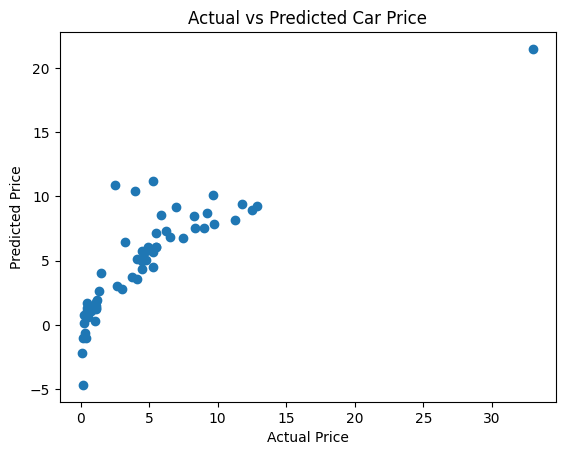

In [21]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()